In [13]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os


In [15]:
 #====================== CONFIG ======================
DB_NAME = 'ipl_2025.db'

# ====================== LOAD DATA ======================
def load_data():
    batters_path = r"C:\Users\nisha\OneDrive\Desktop\IPL Analysis\Dataset\IPL2025Batters.csv"
    bowlers_path = r"C:\Users\nisha\OneDrive\Desktop\IPL Analysis\Dataset\IPL2025Bowlers.csv"
    
    batters = pd.read_csv(batters_path)
    bowlers = pd.read_csv(bowlers_path)
    
    print(f"✅ Successfully loaded Batters: {len(batters)} rows")
    print(f"✅ Successfully loaded Bowlers: {len(bowlers)} rows")
    return batters, bowlers

In [16]:
 #====================== CREATE DATABASE ======================
def create_database(batters, bowlers):
    if os.path.exists(DB_NAME):
        os.remove(DB_NAME)
    
    conn = sqlite3.connect(DB_NAME)
    batters.to_sql('batters', conn, index=False, if_exists='replace')
    bowlers.to_sql('bowlers', conn, index=False, if_exists='replace')
    
    print("✅ SQLite Database created successfully!")
    return conn


In [17]:

# ====================== ANALYSIS ======================
def run_analysis(conn):
    print("\n" + "="*65)
    print("🏏 IPL 2025 DATA ANALYSIS")
    print("="*65)

    queries = {
        "1. Top 10 Run Scorers": """
            SELECT "Player Name", Team, Runs, AVG, SR, "100s", "50s"
            FROM batters ORDER BY Runs DESC LIMIT 10""",
            
        "2. Top 10 Wicket Takers": """
            SELECT "Player Name", Team, WKT, AVG, ECO, SR 
            FROM bowlers ORDER BY WKT DESC LIMIT 10""",
            
        "3. Best Batting Average (Min 10 Inns)": """
            SELECT "Player Name", Team, Runs, AVG, SR, Inn
            FROM batters WHERE Inn >= 10 ORDER BY AVG DESC LIMIT 8""",
            
        "4. Highest Strike Rate (Min 200 Balls)": """
            SELECT "Player Name", Team, Runs, SR, BF
            FROM batters WHERE BF >= 200 ORDER BY SR DESC LIMIT 8"""
    }

    for title, query in queries.items():
        print(f"\n{title}")
        print("-" * len(title))
        df = pd.read_sql_query(query, conn)
        print(df.to_string(index=False))



✅ Successfully loaded Batters: 156 rows
✅ Successfully loaded Bowlers: 108 rows
✅ SQLite Database created successfully!

🏏 IPL 2025 DATA ANALYSIS

1. Top 10 Run Scorers
---------------------
      Player Name Team  Runs   AVG     SR  100s  50s
    Sai Sudharsan   GT   759 54.21 156.17     1    6
Surya Kumar Yadav   MI   717 65.18 167.91     0    5
      Virat Kohli  RCB   657 54.75 144.71     0    8
     Shubman Gill   GT   650 50.00 155.87     0    6
   Mitchell Marsh  LSG   627 48.23 163.70     1    6
     Shreyas Iyer PBKS   604 50.33 175.07     0    6
 Yashasvi Jaiswal   RR   559 43.00 159.71     0    6
Prabhsimran Singh PBKS   549 32.29 160.52     0    4
        K L Rahul   DC   539 53.90 149.72     1    3
      Jos Buttler   GT   538 59.78 163.03     0    5

2. Top 10 Wicket Takers
-----------------------
        Player Name Team  WKT   AVG  ECO    SR
    Prasidh Krishna   GT   25 19.52 8.27 14.16
         Noor Ahmad  CSK   24 17.00 8.16 12.50
     Josh Hazlewood  RCB   22 17.54 

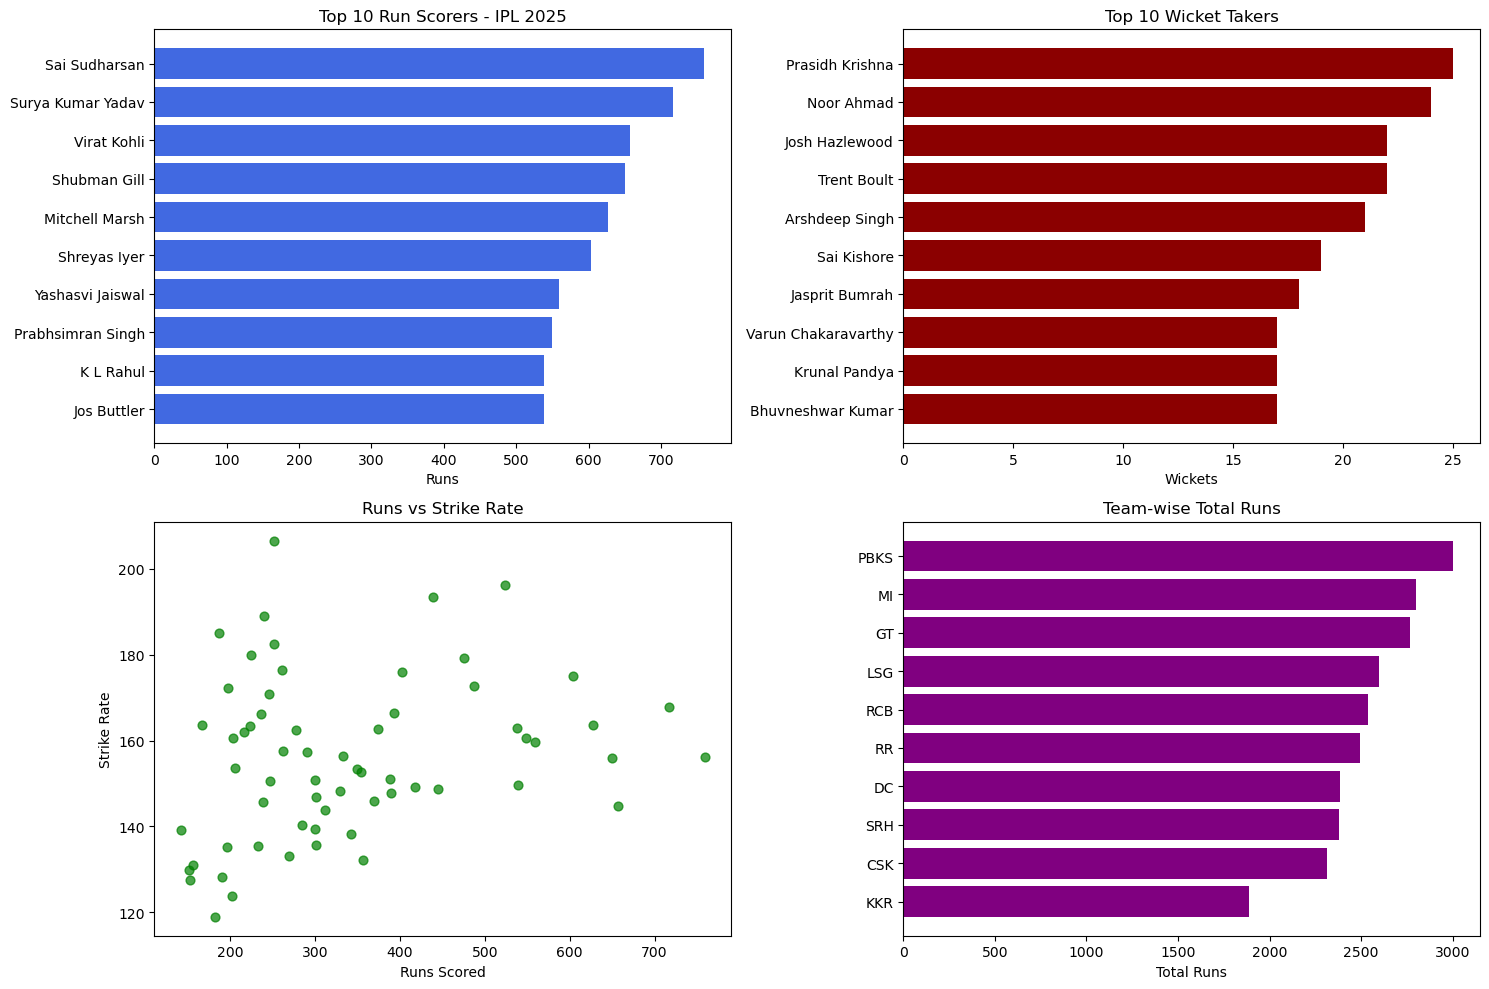


 FULL IPL 2025 ANALYSIS PROJECT COMPLETED SUCCESSFULLY!


In [18]:
# ====================== VISUALIZATIONS ======================
def create_visualizations(conn):
    plt.figure(figsize=(15, 10))

    # Top 10 Batters
    plt.subplot(2, 2, 1)
    df1 = pd.read_sql_query('SELECT "Player Name", Runs FROM batters ORDER BY Runs DESC LIMIT 10', conn)
    plt.barh(df1["Player Name"], df1["Runs"], color='royalblue')
    plt.title("Top 10 Run Scorers - IPL 2025")
    plt.xlabel("Runs")
    plt.gca().invert_yaxis()
 ___________________________________________________________________________________________________________________________________________
    # Top 10 Bowlers
    plt.subplot(2, 2, 2)
    df2 = pd.read_sql_query('SELECT "Player Name", WKT FROM bowlers ORDER BY WKT DESC LIMIT 10', conn)
    plt.barh(df2["Player Name"], df2["WKT"], color='darkred')
    plt.title("Top 10 Wicket Takers")
    plt.xlabel("Wickets")
    plt.gca().invert_yaxis()
_______________________________________________________________________________________________________________________________________________
    # Runs vs Strike Rate - FIXED LINE
    plt.subplot(2, 2, 3)
    df3 = pd.read_sql_query("SELECT Runs, SR FROM batters WHERE BF > 100", conn)
    plt.scatter(df3['Runs'], df3['SR'], alpha=0.7, color='green', s=40)
    plt.xlabel("Runs Scored")
    plt.ylabel("Strike Rate")
    plt.title("Runs vs Strike Rate")
_______________________________________________________________________________________________________________________________________________
    # Team-wise Total Runs
    plt.subplot(2, 2, 4)
    df4 = pd.read_sql_query("""
        SELECT Team, SUM(Runs) as Total_Runs 
        FROM batters GROUP BY Team ORDER BY Total_Runs DESC
    """, conn)
    plt.barh(df4["Team"], df4["Total_Runs"], color='purple')
    plt.title("Team-wise Total Runs")
    plt.xlabel("Total Runs")
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.savefig('ipl_2025_analysis.png', dpi=300, bbox_inches='tight')
    print("\n📊 Charts saved as 'ipl_2025_analysis.png'")
    plt.show()
_______________________________________________________________________________________________________________________________________________
# ====================== MAIN ======================
if __name__ == "__main__":
    batters, bowlers = load_data()
    conn = create_database(batters, bowlers)
    
    run_analysis(conn)
    create_visualizations(conn)
    
    # Export Top 20
    pd.read_sql_query("SELECT * FROM batters ORDER BY Runs DESC LIMIT 20", conn).to_csv('Top_20_Batters.csv', index=False)
    pd.read_sql_query("SELECT * FROM bowlers ORDER BY WKT DESC LIMIT 20", conn).to_csv('Top_20_Bowlers.csv', index=False)
    
    print("\n FULL IPL 2025 ANALYSIS PROJECT COMPLETED SUCCESSFULLY!")
    conn.close()